<a href="https://colab.research.google.com/github/ayatayoub20/intermediate-machine-learning-projects/blob/main/Unsupervised%20Learning%3A%20Clustering/KMeans_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#2. Load Data

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/03-DataEnrichment/Week10/Data/cust_seg.csv')
df.head()

,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,0,1,41,2,6,19,0.124,1.073,0.0,6.3
1,1,2,47,1,26,100,4.582,8.218,0.0,12.8
2,2,3,33,2,10,57,6.111,5.802,1.0,20.9
3,3,4,29,2,4,19,0.681,0.516,0.0,6.3
4,4,5,47,1,31,253,9.308,8.908,0.0,7.2


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 850 entries, 0 to 849
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       850 non-null    int64  
 1   Customer Id      850 non-null    int64  
 2   Age              850 non-null    int64  
 3   Edu              850 non-null    int64  
 4   Years Employed   850 non-null    int64  
 5   Income           850 non-null    int64  
 6   Card Debt        850 non-null    float64
 7   Other Debt       850 non-null    float64
 8   Defaulted        700 non-null    float64
 9   DebtIncomeRatio  850 non-null    float64
dtypes: float64(4), int64(6)
memory usage: 66.5 KB


,Unnamed: 0,Customer Id,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
count,850.00000,850.00000,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,700.000000,850.000000
mean,424.50000,425.50000,35.029412,1.710588,8.565882,46.675294,1.576820,3.078773,0.261429,10.171647
std,245.51816,245.51816,8.041432,0.927784,6.777884,38.543054,2.125843,3.398799,0.439727,6.719441
min,0.00000,1.00000,20.000000,1.000000,0.000000,13.000000,0.012000,0.046000,0.000000,0.100000
25%,212.25000,213.25000,29.000000,1.000000,3.000000,24.000000,0.382500,1.045750,0.000000,5.100000
50%,424.50000,425.50000,34.000000,1.000000,7.000000,35.000000,0.885000,2.003000,0.000000,8.700000
75%,636.75000,637.75000,41.000000,2.000000,13.000000,55.750000,1.898500,3.903250,1.000000,13.800000
max,849.00000,850.00000,56.000000,5.000000,33.000000,446.000000,20.561000,35.197000,1.000000,41.300000


In [4]:
print("Missing values:")
print(df.isna().sum())

print("Duplicated rows:", df.duplicated().sum())

Missing values:
Unnamed: 0           0
Customer Id          0
Age                  0
Edu                  0
Years Employed       0
Income               0
Card Debt            0
Other Debt           0
Defaulted          150
DebtIncomeRatio      0
dtype: int64
Duplicated rows: 0


In [5]:
df = df.drop(columns=['Customer Id','Unnamed: 0'], errors='ignore')
df.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2


#3. Select Features

In [6]:
features = ['Age', 'Edu', 'Years Employed', 'Income', 'Card Debt', 'Other Debt', 'Defaulted', 'DebtIncomeRatio']

X = df[features].copy()
X.head()

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
0,41,2,6,19,0.124,1.073,0.0,6.3
1,47,1,26,100,4.582,8.218,0.0,12.8
2,33,2,10,57,6.111,5.802,1.0,20.9
3,29,2,4,19,0.681,0.516,0.0,6.3
4,47,1,31,253,9.308,8.908,0.0,7.2


#4. Handle Missing Values

In [7]:
X.isna().sum()

,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,150
DebtIncomeRatio,0


In [8]:
X = X.fillna(X.median())

In [9]:
X.isna().sum()

,0
Age,0
Edu,0
Years Employed,0
Income,0
Card Debt,0
Other Debt,0
Defaulted,0
DebtIncomeRatio,0


#5. Scale Data

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#6. Try Different K Values

In [11]:
ks = range(2, 11)

inertias = []
silhouette_scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

#7. Elbow Plot

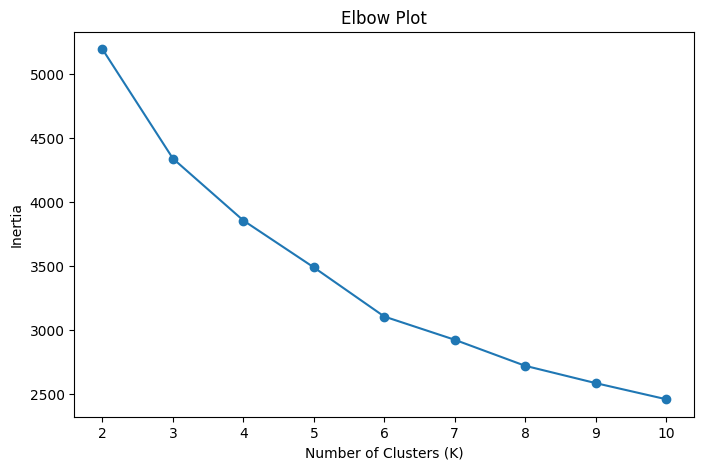

In [12]:
plt.figure(figsize=(8,5))
plt.plot(ks, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Plot')
plt.xticks(ks)
plt.show()

#8. Silhouette Plot

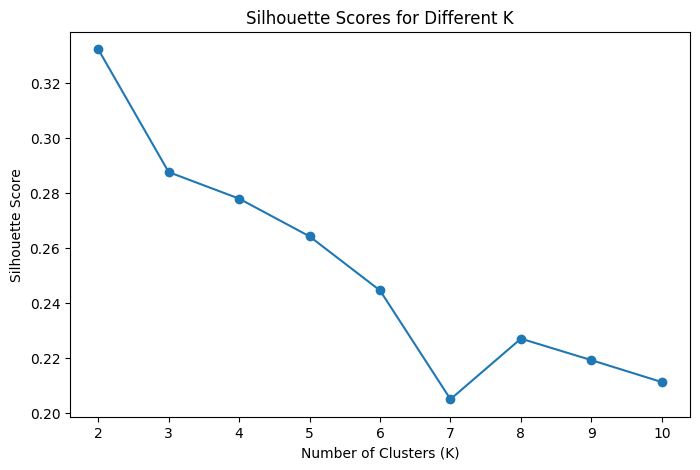

In [13]:
plt.figure(figsize=(8,5))
plt.plot(ks, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for Different K')
plt.xticks(ks)
plt.show()

Based on the Elbow Plot and Silhouette Scores, I chose K = 3.

The Elbow Plot shows a noticeable bend around 3 clusters, indicating that adding more clusters after this point provides smaller improvements in inertia.

Although the highest silhouette score was at K = 2, using only two clusters would create very broad customer groups and reduce the usefulness of the segmentation.

K = 3 provides a better balance between cluster quality and meaningful business insights, making it a suitable choice for customer segmentation.

In [14]:
best_k = 3

final_kmeans = KMeans(n_clusters=best_k,
                      random_state=42,
                      n_init='auto')

final_kmeans.fit(X_scaled)

df['Cluster'] = final_kmeans.labels_

In [15]:
cluster_summary = df.groupby('Cluster')[features].mean()

cluster_summary

,Age,Edu,Years Employed,Income,Card Debt,Other Debt,Defaulted,DebtIncomeRatio
Cluster,,,,,,,,
0,33.827458,1.604824,7.654917,36.181818,0.863681,1.822410,0.000000,7.993506
1,31.891566,1.861446,3.963855,31.789157,1.576675,2.843355,0.993939,13.994578
2,43.089655,1.931034,17.220690,102.724138,4.227897,8.018490,0.165217,13.891724


## Cluster Analysis

### Cluster 0: Low-risk, moderate-income customers

Customers in Cluster 0 are around 34 years old on average, with moderate income and around 7.6 years of employment. They have low card debt, low other debt, and the lowest debt-to-income ratio among the clusters. Also, the default rate is 0, which means these customers appear to be financially responsible and low-risk.

**Insight:** These customers are stable and safe, but they may not be the highest spenders. They are good candidates for standard credit cards with cashback, low fees, and gradual credit limit increases.

---

### Cluster 1: Younger, higher-risk customers

Customers in Cluster 1 are the youngest group on average and have the fewest years of employment. Their income is the lowest, while their debt-to-income ratio is very high. Most importantly, their default rate is almost 1, meaning this group includes customers who are very likely to have defaulted.

**Insight:** These customers seem financially stressed and risky for the credit card company. They may need credit-building products, lower limits, or financial education instead of premium cards.

---

### Cluster 2: Older, high-income customers with high spending

Customers in Cluster 2 are older and have the highest years of employment. They also have the highest income by far. Although they have the highest card debt and other debt, their income is also much higher, so they may be able to manage larger credit balances. Their default rate is relatively low compared to Cluster 1.

**Insight:** These customers are valuable for the company because they have strong income and long employment history. They may be suitable for premium cards, rewards cards, travel benefits, and higher credit limits.

## Recommendations

1. The company should market premium credit cards, travel rewards, cashback programs, and higher credit limits to Cluster 2 because these customers have the highest income, longest employment history, and relatively low default risk.

2. Cluster 1 should be approached carefully because they have low income, short employment history, high debt-to-income ratio, and very high default rate. The company should avoid offering high-limit cards to this group and instead offer secured cards, low-limit credit-building cards, or financial education programs.

3. Cluster 0 can be targeted with standard credit cards, low annual fees, simple cashback offers, and gradual credit limit increases because they are low-risk customers with moderate income and very low default behavior.